# Machine Learning Analysis

This notebook applies machine learning methods to the Syria host-country panel dataset for the May 5 milestone.

The goal is to explore whether refugee exposure, conflict intensity, and macroeconomic indicators can help predict host-country economic outcomes.

The current version focuses on the Syrian Civil War as a case study. The host countries are Turkey, Lebanon, and Jordan. The dataset covers the years 2010–2024.



In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Define project paths

DATA_PATH = Path("../data/processed/syria_panel_2010_2024.csv")
FIGURE_DIR = Path("../outputs/figures")
TABLE_DIR = Path("../outputs/tables")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Load the processed Syria panel dataset

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (45, 16)


,origin_name,origin_iso,host_name,host_iso,year,conflict_bd_best_syria,refugee_stock,asylum_seekers,host_population,refugees_per_1000,log_refugee_stock,gdp_growth,inflation,unemployment,trade_pct_gdp,current_account_pct_gdp
0,Syria,SYR,Jordan,JOR,2010,0.0,198,287,7297043.0,0.027134,5.293305,2.314834,4.845519,12.5,114.222678,-6.935807
1,Syria,SYR,Jordan,JOR,2011,1203.0,193,2618,7480424.0,0.025801,5.267858,2.737180,4.162442,12.9,118.699680,-10.012201
2,Syria,SYR,Jordan,JOR,2012,50490.0,238798,491,7587127.0,31.474101,12.383377,2.429358,4.515230,12.2,117.855588,-14.892690
3,Syria,SYR,Jordan,JOR,2013,72016.0,585304,0,7991809.0,73.237987,13.279888,2.609947,4.824623,12.6,111.451528,-10.169584
4,Syria,SYR,Jordan,JOR,2014,65345.0,623112,0,8791710.0,70.874949,13.342483,3.384078,2.899479,11.9,109.938806,-7.077870


In [4]:
# Check columns and missing values

print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

Columns:
['origin_name', 'origin_iso', 'host_name', 'host_iso', 'year', 'conflict_bd_best_syria', 'refugee_stock', 'asylum_seekers', 'host_population', 'refugees_per_1000', 'log_refugee_stock', 'gdp_growth', 'inflation', 'unemployment', 'trade_pct_gdp', 'current_account_pct_gdp']

Missing values:
origin_name                0
origin_iso                 0
host_name                  0
host_iso                   0
year                       0
conflict_bd_best_syria     0
refugee_stock              0
asylum_seekers             0
host_population            0
refugees_per_1000          0
log_refugee_stock          0
gdp_growth                 1
inflation                  0
unemployment               1
trade_pct_gdp              1
current_account_pct_gdp    1
dtype: int64


In [5]:
# Quick overview of countries and years

print("Host countries:", df["host_name"].unique())
print("Year range:", df["year"].min(), "-", df["year"].max())

df.groupby("host_name")["year"].agg(["min", "max", "count"])

Host countries: <StringArray>
['Jordan', 'Lebanon', 'Turkey']
Length: 3, dtype: str
Year range: 2010 - 2024


,min,max,count
host_name,,,
Jordan,2010,2024,15
Lebanon,2010,2024,15
Turkey,2010,2024,15


In [6]:
# Select variables for machine learning

target = "gdp_growth"

numeric_features = [
    "conflict_bd_best_syria",
    "refugees_per_1000",
    "log_refugee_stock",
    "inflation",
    "unemployment",
    "trade_pct_gdp",
    "current_account_pct_gdp",
    "year"
]

categorical_features = ["host_name"]

ml_columns = [target] + numeric_features + categorical_features

ml_df = df[ml_columns].copy()

print("ML dataset shape before cleaning:", ml_df.shape)
ml_df.head()

ML dataset shape before cleaning: (45, 10)


,gdp_growth,conflict_bd_best_syria,refugees_per_1000,log_refugee_stock,inflation,unemployment,trade_pct_gdp,current_account_pct_gdp,year,host_name
0,2.314834,0.0,0.027134,5.293305,4.845519,12.5,114.222678,-6.935807,2010,Jordan
1,2.737180,1203.0,0.025801,5.267858,4.162442,12.9,118.699680,-10.012201,2011,Jordan
2,2.429358,50490.0,31.474101,12.383377,4.515230,12.2,117.855588,-14.892690,2012,Jordan
3,2.609947,72016.0,73.237987,13.279888,4.824623,12.6,111.451528,-10.169584,2013,Jordan
4,3.384078,65345.0,70.874949,13.342483,2.899479,11.9,109.938806,-7.077870,2014,Jordan


In [7]:
# Drop rows with missing values in selected ML columns

ml_df = ml_df.dropna()

print("ML dataset shape after cleaning:", ml_df.shape)
print("\nMissing values after cleaning:")
print(ml_df.isna().sum())

ML dataset shape after cleaning: (44, 10)

Missing values after cleaning:
gdp_growth                 0
conflict_bd_best_syria     0
refugees_per_1000          0
log_refugee_stock          0
inflation                  0
unemployment               0
trade_pct_gdp              0
current_account_pct_gdp    0
year                       0
host_name                  0
dtype: int64


In [8]:
# Define features and target

X = ml_df[numeric_features + categorical_features]
y = ml_df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (44, 9)
Target shape: (44,)


In [9]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (33, 9)
Test set: (11, 9)


In [10]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

In [11]:
# Define a function for model evaluation

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        "model": model_name,
        "target": target,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [12]:
# Train Linear Regression model

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

linear_results

{'model': 'Linear Regression',
 'target': 'gdp_growth',
 'MAE': 3.9493831990042554,
 'RMSE': np.float64(5.987348403156129),
 'R2': 0.4875223695422549}

In [13]:
# Train Decision Tree Regressor model

tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=3,
            random_state=42
        ))
    ]
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

tree_results = evaluate_model(
    "Decision Tree Regressor",
    y_test,
    tree_predictions
)

tree_results

{'model': 'Decision Tree Regressor',
 'target': 'gdp_growth',
 'MAE': 4.663034841488011,
 'RMSE': np.float64(8.585126910352832),
 'R2': -0.053657084299512325}

In [14]:
# Compare model results

results_df = pd.DataFrame([linear_results, tree_results])

results_df

,model,target,MAE,RMSE,R2
0,Linear Regression,gdp_growth,3.949383,5.987348,0.487522
1,Decision Tree Regressor,gdp_growth,4.663035,8.585127,-0.053657


In [15]:
# Create actual vs predicted comparison for GDP growth

prediction_df = pd.DataFrame({
    "actual_gdp_growth": y_test.values,
    "linear_prediction": linear_predictions,
    "tree_prediction": tree_predictions
})

prediction_df

,actual_gdp_growth,linear_prediction,tree_prediction
0,3.468153,1.838137,4.237667
1,-6.914925,-0.223269,1.828215
2,-21.399900,-6.155840,4.237667
3,7.825857,2.856884,4.237667
4,5.805574,4.052109,4.237667
5,11.811094,2.786936,4.237667
6,3.384078,2.987829,1.828215
7,2.647435,2.840931,1.828215
8,1.919071,-0.029911,1.828215
9,2.609947,3.570262,1.828215


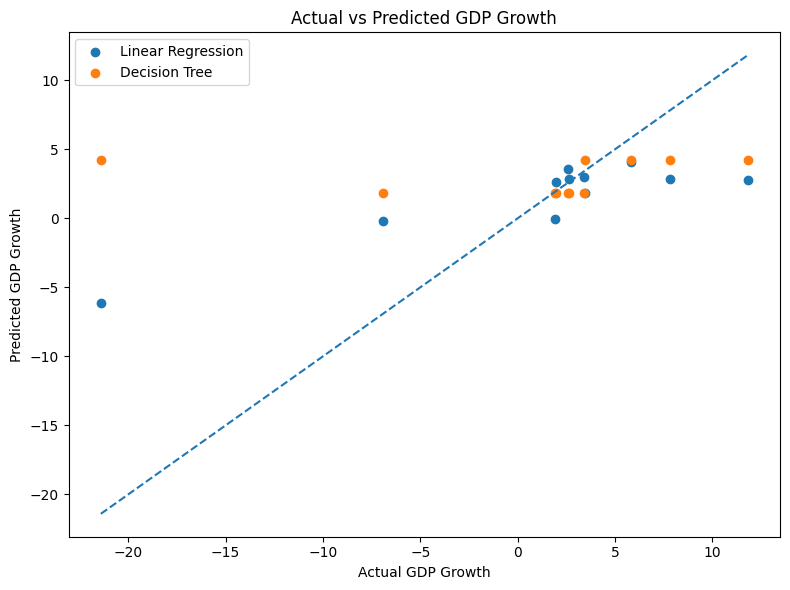

Saved figure to: ../outputs/figures/syria_ml_actual_vs_predicted_gdp_growth.png


In [16]:
# Plot actual vs predicted values

plt.figure(figsize=(8, 6))

plt.scatter(prediction_df["actual_gdp_growth"], prediction_df["linear_prediction"], label="Linear Regression")
plt.scatter(prediction_df["actual_gdp_growth"], prediction_df["tree_prediction"], label="Decision Tree")

min_value = min(
    prediction_df["actual_gdp_growth"].min(),
    prediction_df["linear_prediction"].min(),
    prediction_df["tree_prediction"].min()
)

max_value = max(
    prediction_df["actual_gdp_growth"].max(),
    prediction_df["linear_prediction"].max(),
    prediction_df["tree_prediction"].max()
)

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual GDP Growth")
plt.ylabel("Predicted GDP Growth")
plt.title("Actual vs Predicted GDP Growth")
plt.legend()
plt.tight_layout()

figure_path = FIGURE_DIR / "syria_ml_actual_vs_predicted_gdp_growth.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [17]:
# Get feature names after preprocessing

feature_names = tree_model.named_steps["preprocessor"].get_feature_names_out()

tree_importances = tree_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": tree_importances
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
2,num__log_refugee_stock,0.483417
3,num__inflation,0.404596
4,num__unemployment,0.093946
7,num__year,0.017473
1,num__refugees_per_1000,0.000569
0,num__conflict_bd_best_syria,0.000000
5,num__trade_pct_gdp,0.000000
6,num__current_account_pct_gdp,0.000000
8,cat__host_name_Lebanon,0.000000
9,cat__host_name_Turkey,0.000000


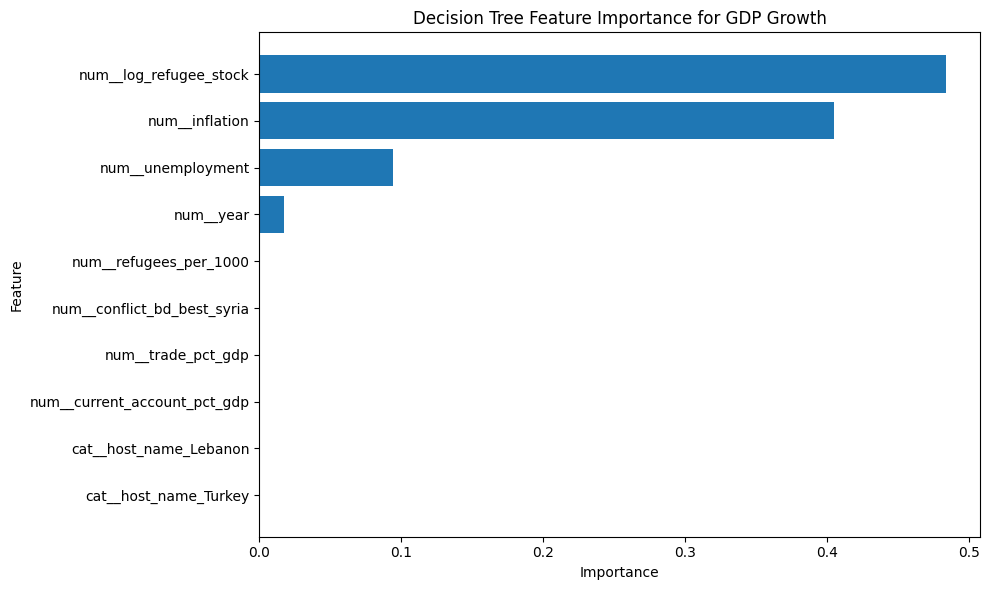

Saved figure to: ../outputs/figures/syria_ml_feature_importance_gdp_growth.png


In [18]:
# Plot feature importance

plt.figure(figsize=(10, 6))

plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance for GDP Growth")
plt.gca().invert_yaxis()
plt.tight_layout()

figure_path = FIGURE_DIR / "syria_ml_feature_importance_gdp_growth.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

## Preliminary ML Interpretation

The ML models were used to predict GDP growth using refugee exposure, conflict intensity, and macroeconomic indicators.

Because the dataset is small, the results are exploratory and should not be interpreted as strong causal evidence.

Linear Regression was used as a simple baseline model, while the Decision Tree Regressor was used to capture possible non-linear patterns. The evaluation table compares the models using MAE, RMSE, and R².